Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE" and remove every line containing the expression: "raise ..." (if you leave such a line your code will not run).

Do not remove any cell from the notebook you downloaded. You can add any number of cells (and remove them if not more necessary). 

## IMPORTANT: make sure to rerun all the code from the beginning to obtain the results for the final version of your notebook, since this is the way we will do it before evaluating your notebook!!!

## Make sure to name your notebook file (.ipynb) correctly:
### - RR_NAMESURNAME_ID (E.g. : RR_MARIOROSSI_2204567)

## Fill in your name, surname and id number (numero matricola) below:

In [1]:
# Reproducible project seed, not a university registration number.
NAME = "Stelina Mukaj"
ID_number = 42  # Replace with your matricola only if submitting to the course.
import numpy as np
np.random.seed(ID_number)


---

#  Regression on House Pricing Dataset: Variable Selection & Regularization

We will consider a reduced version of a dataset containing house sale prices for King County, which includes Seattle. It includes homes sold between May 2014 and May 2015.

Dataset used:
https://www.kaggle.com/harlfoxem/housesalesprediction

{
Kaggle competition on house prices:
https://www.kaggle.com/c/house-prices-advanced-regression-techniques
}

For each house we know 17 house features (e.g., number of bedrooms, number of bathrooms, etc.) plus its price, that is what we would like to predict.

In [2]:
#import all packages needed
from __future__ import division
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

import warnings
# Keep convergence warnings visible.

np.random.seed(ID_number)


In [3]:
url = "https://raw.githubusercontent.com/LucaZancato/ML2020-2021/main/kc_house_data.csv"

data = pd.read_csv(url, sep=',')

# Remove the data samples with missing values (NaN)
data = data.dropna()
# Remove the houses with waterfront
data = data.drop(data[data['waterfront']==1].index)
# Remove the columns we are not going to use
data = data.drop(columns=['id', 'date','waterfront'])
# Have a brief description of the dataset

data.describe()


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,3.133000e+03,3133.00000,3133.000000,3133.000000,3.133000e+03,3133.000000,3133.000000,3133.000000,3133.000000,3133.00000,3133.000000,3133.000000,3133.000000,3133.000000,3133.000000,3133.000000,3133.000000,3133.000000
mean,5.215503e+05,3.38270,2.064395,2057.023300,1.504079e+04,1.432493,0.210022,3.456751,7.604532,1751.96489,305.058410,1967.499202,91.785828,98077.015640,47.557970,-122.211718,1975.721992,13058.278966
std,3.287423e+05,0.89238,0.755714,893.008107,4.181746e+04,0.506179,0.696599,0.681677,1.147630,798.72648,451.879253,28.109695,418.255205,54.133958,0.141078,0.139451,680.033180,25419.485855
min,7.500000e+04,0.00000,0.000000,380.000000,6.490000e+02,1.000000,0.000000,1.000000,3.000000,380.00000,0.000000,1900.000000,0.000000,98001.000000,47.177500,-122.502000,620.000000,660.000000
25%,3.150000e+05,3.00000,1.500000,1422.000000,5.427000e+03,1.000000,0.000000,3.000000,7.000000,1190.00000,0.000000,1950.000000,0.000000,98032.000000,47.459800,-122.324000,1480.000000,5413.000000
50%,4.420000e+05,3.00000,2.000000,1900.000000,7.956000e+03,1.000000,0.000000,3.000000,7.000000,1540.00000,0.000000,1969.000000,0.000000,98059.000000,47.572600,-122.226000,1830.000000,7818.000000
75%,6.350000e+05,4.00000,2.500000,2490.000000,1.111100e+04,2.000000,0.000000,4.000000,8.000000,2130.00000,600.000000,1990.000000,0.000000,98117.000000,47.680500,-122.124000,2350.000000,10300.000000
max,5.350000e+06,8.00000,5.500000,8000.000000,1.651359e+06,3.500000,4.000000,5.000000,12.000000,6720.00000,2620.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,5790.000000,425581.000000


In [4]:
# Print first 5 datapoints of the dataset
data.head()


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340.0,5650.0
1,538000.0,3,2.25,2570,7242,2.0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690.0,7639.0
2,180000.0,2,1.00,770,10000,1.0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720.0,8062.0
3,604000.0,4,3.00,1960,5000,1.0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360.0,5000.0
4,510000.0,3,2.00,1680,8080,1.0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800.0,7503.0


In [5]:
# Let's look at all the possible independent variables and get an idea of our data. Do not forget we are going 
# to predict the variable 'price' using all the other features 
data.columns


Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built',
       'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15',
       'sqft_lot15'],
      dtype='object')

In [6]:
# Let's split data into train and test using sklearn built-in function: train_test_split (have a look at the 
# documentation)
m_t, m = 100, len(data)
m_test = m - m_t

from sklearn.model_selection import train_test_split
train_data, test_data = train_test_split(data, train_size=m_t, random_state=ID_number)


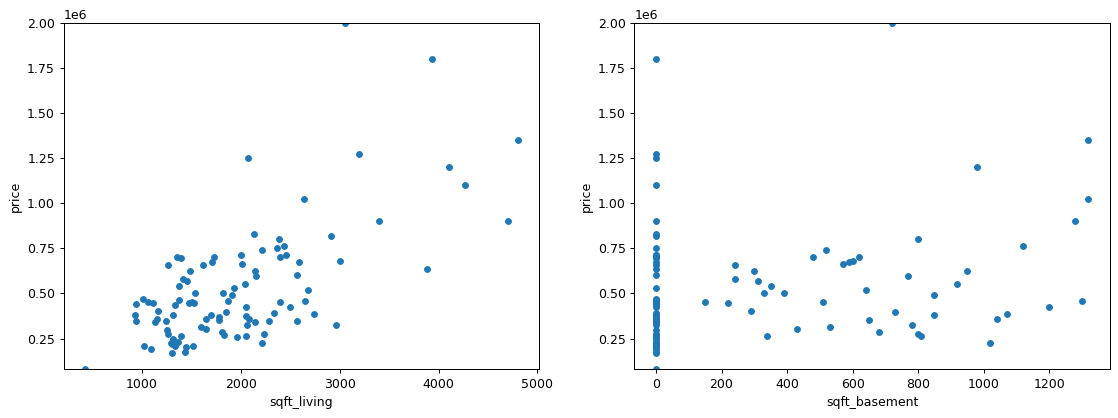

In [7]:
# Let's check the price trend as a function of the sqrt_living and sqrt_basement (separately)

def plot_single_feature_vs_y(feature, train_data, ax=None, y='price'):
    reduced_data = pd.concat([train_data[y], train_data[feature]], axis=1)
    reduced_data.plot.scatter(x=feature, y=y, ylim=(train_data[y].min(), train_data[y].max()), ax=ax)

fig, axes = plt.subplots(1,2, figsize=(15,5))
plot_single_feature_vs_y('sqft_living', train_data, ax=axes[0])
plot_single_feature_vs_y('sqft_basement', train_data, ax=axes[1])

# Note 'sqft_basement' might not be easily used to predict Y (many values are zero while 'price' has different values)


In [8]:
# Let's explore data and features distributions using box plots
def box_plot_single_feature_vs_y(feature, train_data):
    plt.figure(figsize=(15,10))
    reduced_data = pd.concat([train_data['price'], train_data[feature]], axis=1)
    sns.boxplot(x=feature, y="price", data=reduced_data)


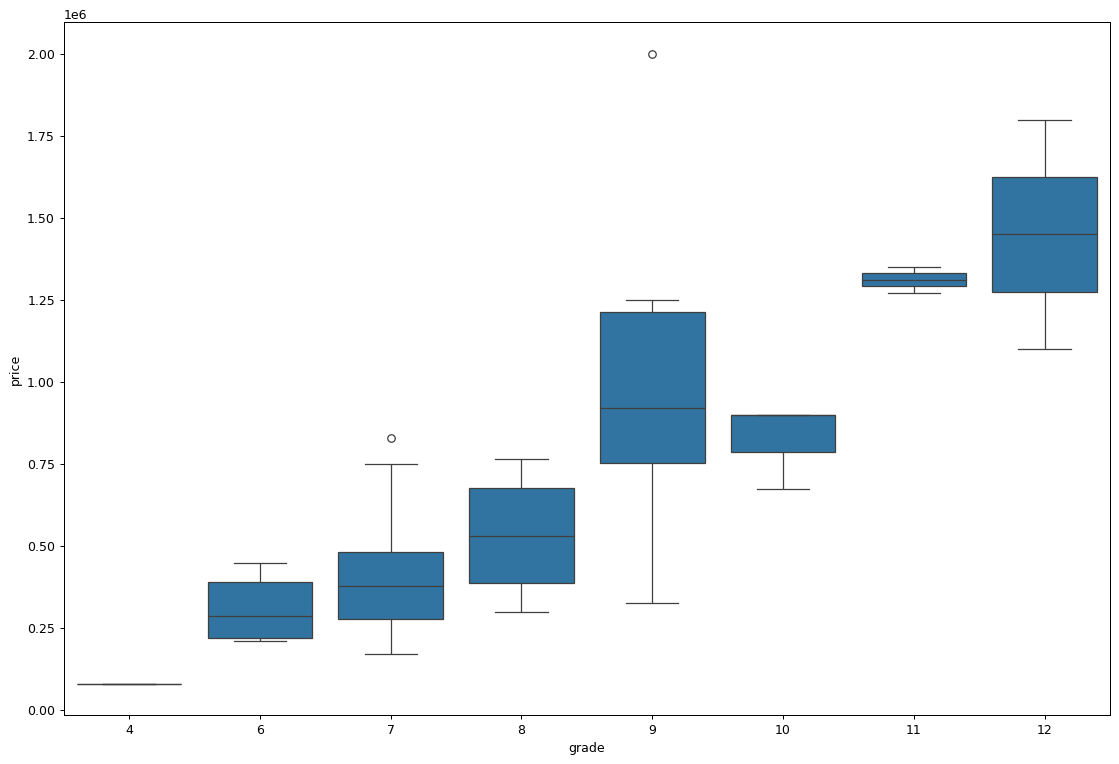

In [9]:
# Prices over 'grade'

box_plot_single_feature_vs_y('grade', train_data)


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59], [Text(0, 0, '1900'), Text(1, 0, '1906'), Text(2, 0, '1908'), Text(3, 0, '1910'), Text(4, 0, '1911'), Text(5, 0, '1912'), Text(6, 0, '1916'), Text(7, 0, '1920'), Text(8, 0, '1928'), Text(9, 0, '1930'), Text(10, 0, '1937'), Text(11, 0, '1940'), Text(12, 0, '1941'), Text(13, 0, '1942'), Text(14, 0, '1945'), Text(15, 0, '1947'), Text(16, 0, '1949'), Text(17, 0, '1950'), Text(18, 0, '1951'), Text(19, 0, '1952'), Text(20, 0, '1953'), Text(21, 0, '1954'), Text(22, 0, '1955'), Text(23, 0, '1956'), Text(24, 0, '1957'), Text(25, 0, '1958'), Text(26, 0, '1959'), Text(27, 0, '1960'), Text(28, 0, '1961'), Text(29, 0, '1962'), Text(30, 0, '1963'), Text(31, 0, '1964'), Text(32, 0, '1966'), Text(33, 0, '1967'), Text(34, 0, '1968'), Text(35, 0, '1969'), Text(36, 0, '1970'),

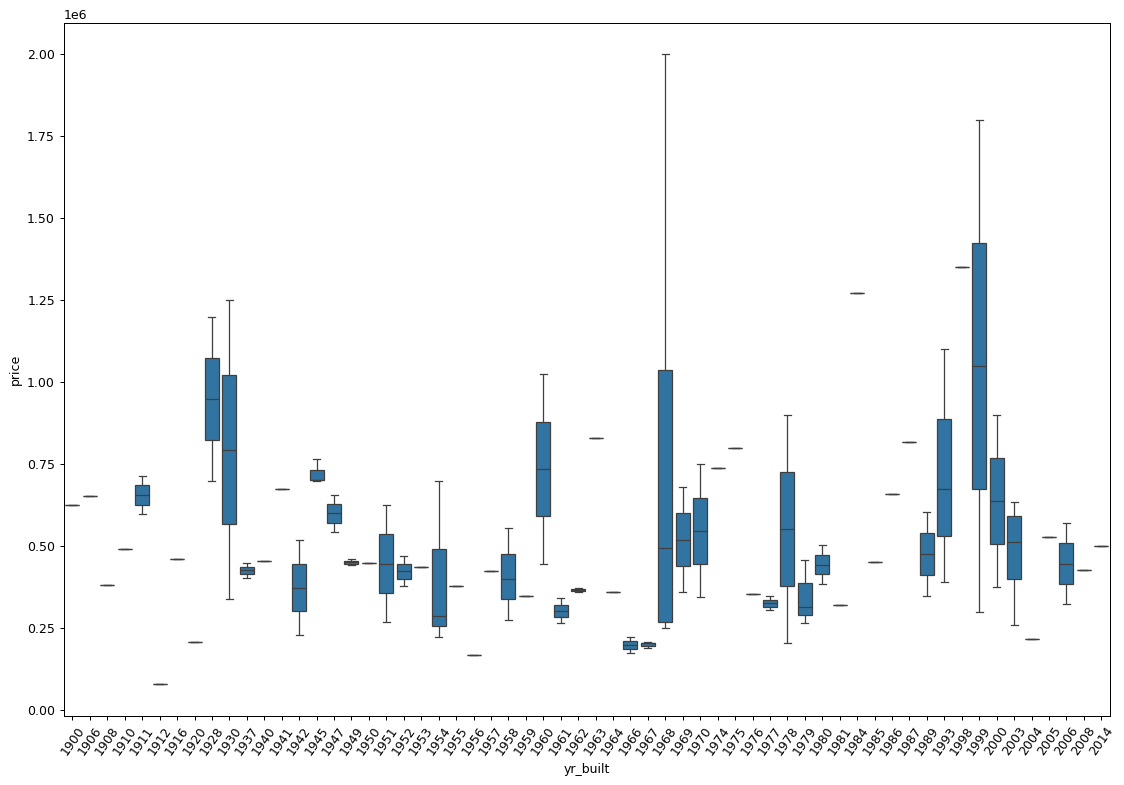

In [10]:
# Prices over 'yr_built'

box_plot_single_feature_vs_y('yr_built', train_data)
plt.xticks(rotation=55)


**Note**: 'grade' seems to correlate well with the regression variable 'price' (the higher the 'grade' the higher the
 'price'). On the other hand it is not clear whether there is correlation between 'yr_built' and 'price'.
 You can try to inspect other features and how they correlate with 'price'.

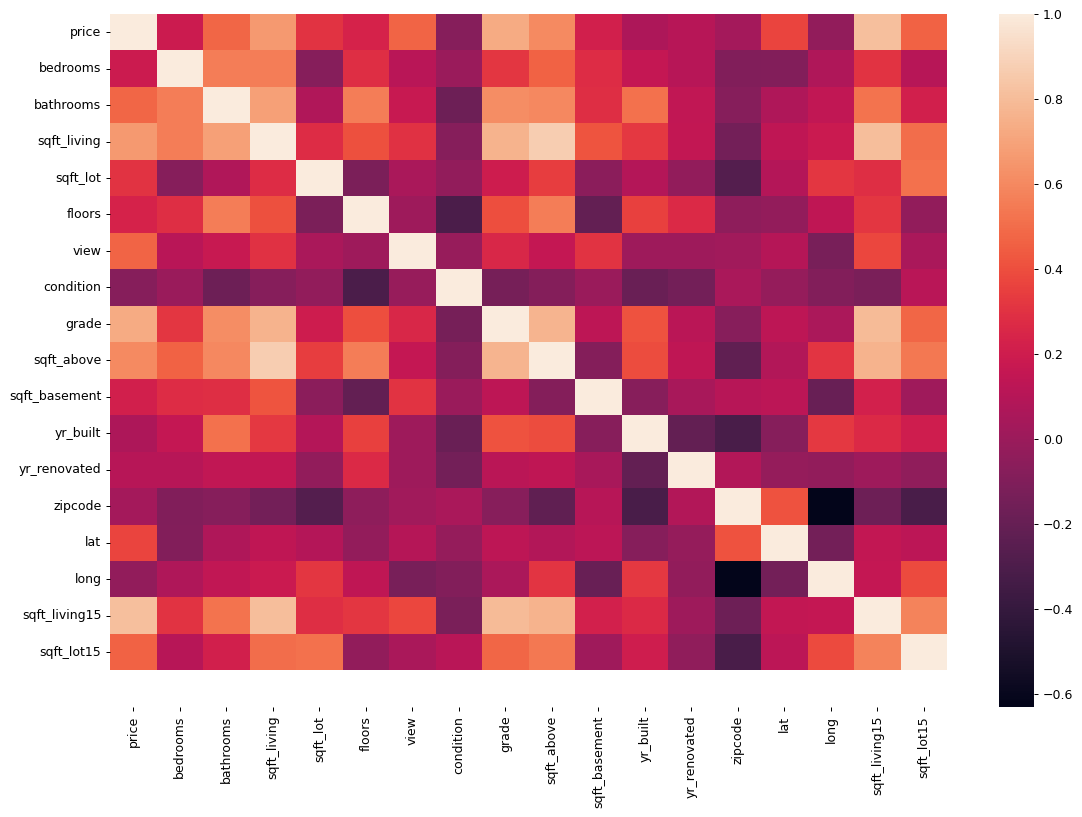

In [11]:
# Let's' try to make the process we followed up to now a little bit more systematic: we will use a pandas 
# built-in function to plot the correlation matrix between all the features and the regression variables.

def plot_correlation_matrix(df_train):
    plt.subplots(figsize=(15, 10))
    corr_matrix = df_train.corr()
    ax = sns.heatmap(corr_matrix, vmax=1, square=False)
    ax.set_ylim(19, 0)
    return corr_matrix

corr_matrix = plot_correlation_matrix(train_data)


(19.0, 0.0)

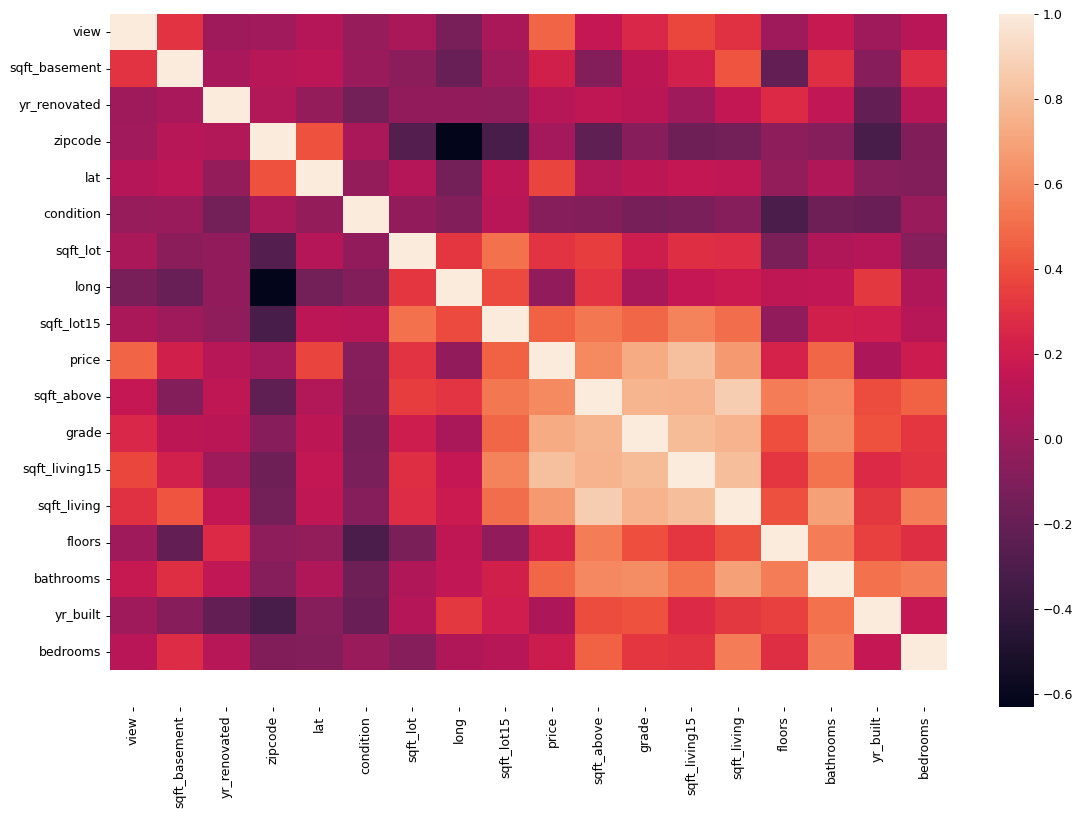

In [12]:
# Previous correlation matrix is not ordered, we need to sort its entries such that we can cluster the most 
# correlated variables. In this way it will be easier to read the correlation matrix.

import scipy
import scipy.cluster.hierarchy as sch

def cluster_corr(corr_array, inplace=False) -> pd.DataFrame:
    """
    Rearranges the correlation matrix, corr_array, so that groups of highly 
    correlated variables are next to eachother 
    
    :param corr_array: pandas.DataFrame or numpy.ndarray a NxN correlation matrix 
        
    :returns: A NxN correlation matrix with the columns and rows rearranged
    """
    pairwise_distances = sch.distance.pdist(corr_array)
    linkage = sch.linkage(pairwise_distances, method='complete')
    cluster_distance_threshold = pairwise_distances.max()/2
    idx_to_cluster_array = sch.fcluster(linkage, cluster_distance_threshold, 
                                        criterion='distance')
    idx = np.argsort(idx_to_cluster_array)
    
    if not inplace:
        corr_array = corr_array.copy()
    
    if isinstance(corr_array, pd.DataFrame):
        return corr_array.iloc[idx, :].T.iloc[idx, :]
    return corr_array[idx, :][:, idx]

plt.subplots(figsize=(15, 10))
corr_matrix = cluster_corr(corr_matrix, inplace=False)
ax = sns.heatmap(corr_matrix, vmax=1, square=False)
ax.set_ylim(19, 0)


Note the 'clusters' along the diagonal. Actually, some of these correlations are so strong that it might indicate a situation of multicollinearity. 
This means these varaibles are in some sense redundant (they give almost the same information) and might not be useful to build our final linear model.

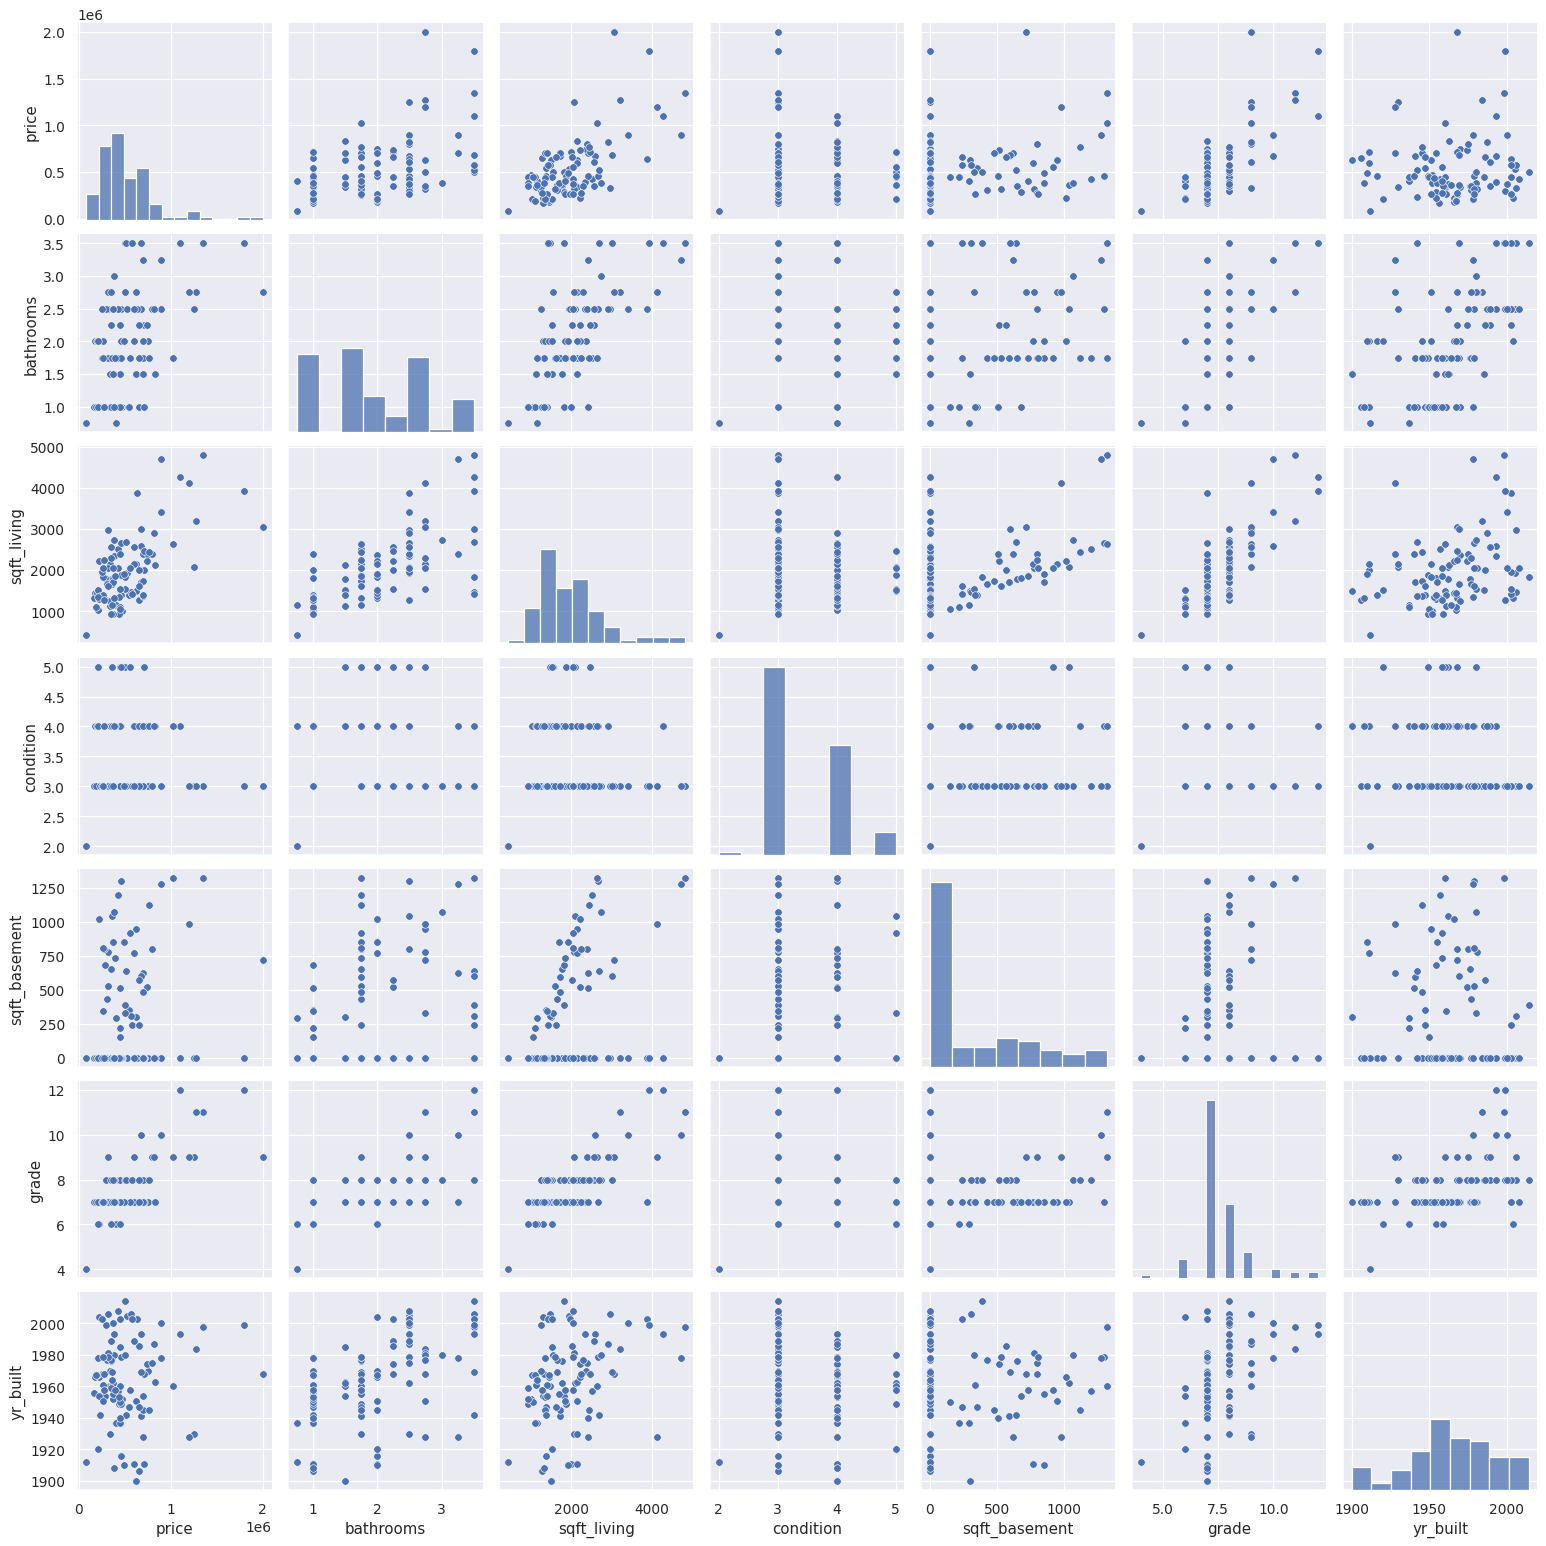

In [13]:
# Let's have a look at some scatter plots (in the main diagonal there is a histogram with the actual data)
sns.set()
cols = ['price', 'bathrooms', 'sqft_living', 'condition', 'sqft_basement', 'grade', 'yr_built']
sns.pairplot(train_data[cols], height = 2.5)
plt.show()
# As we see in the correlation matrix 'condition' and 'yr_build' are very poorly correlated


**Note**: We can remove features that we believe are much correlated with others (leaving at least one of them), since they can be thought as redundant. Don't forget we should keep into account how much each feature is correlated with the regression variable too.

In [14]:
# Let's now standardize the data as we did in the past homeworks
features_names = train_data.columns[1:]
x_train, y_train = train_data[features_names].values.astype('float'), train_data['price'].values.astype('float')
x_test, y_test = test_data[features_names].values.astype('float'), test_data['price'].values.astype('float')

from sklearn import preprocessing
scaler_x = preprocessing.StandardScaler().fit(x_train)
x_train = scaler_x.transform(x_train)

scaler_y = preprocessing.StandardScaler().fit(y_train.reshape(-1,1))
y_train = scaler_y.transform(y_train.reshape(-1,1)).reshape(-1,)

x_test = scaler_x.transform(x_test)
y_test = scaler_y.transform(y_test.reshape(-1,1)).reshape(-1,)


In [15]:
from sklearn import linear_model

def model_results(model,x_train,y_train,x_test,y_test):
    model.fit(x_train,y_train)
    w = np.r_[np.asarray(model.intercept_).ravel(), model.coef_.ravel()]
    return np.float64(model.score(x_train,y_train)), np.float64(model.score(x_test,y_test)), w

def solve_LS_problem(x_train,y_train,x_test,y_test):
    return model_results(linear_model.LinearRegression(),x_train,y_train,x_test,y_test)


In [16]:
COD_train_LS_full, COD_test_LS_full, w_LS_full = solve_LS_problem(x_train, y_train, x_test, y_test)
print(f"Coefficient of determination on training data: {COD_train_LS_full:.4f}")
print(f"Coefficient of determination on test data:     {COD_test_LS_full:.4f}")
print(f"w_LS_full:{w_LS_full}")

assert w_LS_full.shape == (18,)
assert type(COD_train_LS_full) == np.float64 and COD_train_LS_full <= 1.0
assert type(COD_test_LS_full) == np.float64 and COD_test_LS_full <= 1.0


Coefficient of determination on training data: 0.8311
Coefficient of determination on test data:     0.5118
w_LS_full:[-2.72931080e-15 -6.17024874e-02  2.38440050e-01 -8.25346206e-02
  1.01254629e-01 -4.24933656e-03  1.82463902e-01  1.64079784e-02
  3.13655849e-01 -5.55445434e-02 -6.41864397e-02 -2.48944800e-01
  1.35354051e-02 -3.70666498e-02  2.05133062e-01 -7.15913617e-02
  5.11020784e-01  2.56051015e-02]


### TODO 2: explain the results
Explain the effect of the pre-processing on the first value of w_LS_full.

The first coefficient is the intercept $b=\bar y-\bar x^T w$. Both features and target have zero training mean after standardization, so the fitted intercept is zero up to floating-point error. This does not mean the intercept in the original units is zero; inverse transformation restores the original means and scales.


In [17]:
# TODO 3
# Based on the observations we made earlier looking at the dataset (correlation and scatter plots) which variables 
# would you choose to predict the price? Choose the 4 most important features based on your intuition.
# Here we plot features and their indeces for your ease of use
print({index: feature for index, feature in enumerate(features_names)})


{0: 'bedrooms', 1: 'bathrooms', 2: 'sqft_living', 3: 'sqft_lot', 4: 'floors', 5: 'view', 6: 'condition', 7: 'grade', 8: 'sqft_above', 9: 'sqft_basement', 10: 'yr_built', 11: 'yr_renovated', 12: 'zipcode', 13: 'lat', 14: 'long', 15: 'sqft_living15', 16: 'sqft_lot15'}


In [18]:
hand_selected_names = ['sqft_living','grade','lat','view']
hand_selected_features_indeces = [features_names.get_loc(f) for f in hand_selected_names]
COD_train_LS_reduced, COD_test_LS_reduced, w_LS_reduced = solve_LS_problem(
    x_train[:,hand_selected_features_indeces],y_train,x_test[:,hand_selected_features_indeces],y_test)
print("Selected features:",hand_selected_names)
print("Training R²:",COD_train_LS_reduced,"Test R²:",COD_test_LS_reduced)


Selected features: ['sqft_living', 'grade', 'lat', 'view']
Training R²: 0.6955385630714099 Test R²: 0.6081516094397554


In [19]:
assert w_LS_reduced.shape == (5,)


### TODO 4: 
What is your reasoning behind the choice of the 4 features you selected in the todo 3?  

Living area represents house size; grade represents construction quality; latitude represents location; and view represents an amenity that can command a premium. This combines distinct sources of predictive information rather than several near-duplicate area measurements. It is a defensible manual hypothesis, not a claim that these are the globally optimal four features; best-subset validation below tests competing choices using training/validation data.


## Best-Subset Selection

What if we try a brute force approach? Are the features you selected the same as the ones you would get by looking at all the possible combinations?

In the next cell we are going to split x_train into a ("new") training dataset (x_train_BSS) and validation dataset (x_val_BSS) to perform best-subset selection (remember the validation dataset is used to find the best generalizing model among the ones, with different number of features, you trained using x_train_BSS). 

We are going to choose subsets of features going from $1$ to $n_{sub}=4$. In theory we should try all the possible combinations of size $1,2, \dots, 18$ but the number of models to train and validate would be huge! For the sake of simplicity we will choose all the possible subsets of dimension $1$ to $4$.

Steps:
1. Compute the LS estimate using all the possible subsets of $k$ features
2. Compute the prediction error on the validation dataset
3. Choose the subset of $k^*$ features giving the lowest validation error

In [20]:
# TODO 5 
# Let's get the validation dataset from the training dataset (don't forget they must be disjoint, of course we could 
# have splitted them before, during the pre-processing step)
import itertools

m_train_BSS, m_val_BSS = m_t // 2, m_t - m_t // 2

x_train_BSS, y_train_BSS = x_train[:m_train_BSS], y_train[:m_train_BSS]
x_val_BSS, y_val_BSS = x_train[m_train_BSS:], y_train[m_train_BSS:]


nsub = 4
features_idx_dict, validation_err_dict = {}, {}
for k in range(1,nsub + 1):
    features_idx = list(itertools.combinations(range(x_train_BSS.shape[1]), k))
    validation_error = np.zeros(len(features_idx),)
    for j in range(len(features_idx)):
        # You should use the function you built in previous TODO
        idx = list(features_idx[j])
        _, COD_val_BSS, _ = solve_LS_problem(x_train_BSS[:,idx], y_train_BSS, x_val_BSS[:,idx], y_val_BSS)
        validation_error[j] = 1 - COD_val_BSS
    print(f'Number of models trained for {k} chosen features: {len(features_idx)}')
    
    features_idx_dict.update({k: features_idx})
    validation_err_dict.update({k: validation_error})
    
validation_err_min_per_size = {k+1: np.min(val_errs) for k, val_errs in enumerate(validation_err_dict.values())}
validation_err_argmin_per_size = {k+1: np.argmin(val_errs) for k, val_errs in enumerate(validation_err_dict.values())}


Number of models trained for 1 chosen features: 17
Number of models trained for 2 chosen features: 136
Number of models trained for 3 chosen features: 680
Number of models trained for 4 chosen features: 2380


In [21]:
number_subsets_per_group = [int(scipy.special.comb(17, k)) for k in range(1, nsub + 1)]
for k, n_SubSet in zip(range(1, nsub + 1), number_subsets_per_group): 
    assert len(validation_err_dict[k]) == n_SubSet
    


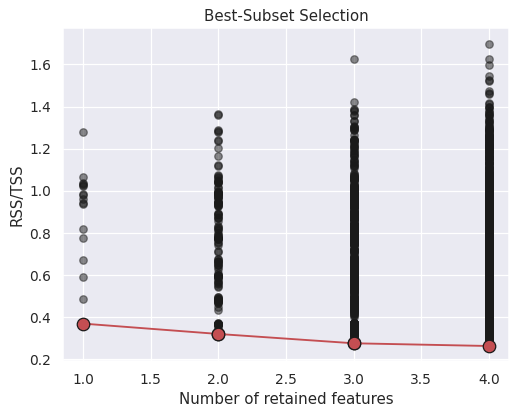

In [22]:
# Plot the validation score for each model
plt.figure(2)
for k in range(1,nsub+1):
    plt.scatter(k*np.ones(validation_err_dict[k].shape), validation_err_dict[k], color='k', alpha=0.5)
    if k > 1:
        plt.plot([k-1, k], [validation_err_min_per_size[k-1], validation_err_min_per_size[k]], color='r',marker='o', 
            markeredgecolor='k', markerfacecolor = 'r', markersize = 10)
plt.xlabel('Number of retained features')
plt.ylabel('RSS/TSS')
plt.title('Best-Subset Selection')
plt.show()


In [23]:
# TODO 6
# Pick the number of features for the best subset according to figure above, select the best subset using the results 
# above and learn the model on the entire training data (x_train); eventually compute COD on training (x_train) and 
# on test data (x_test).

# Now pick the number of features according to best subset
opt_num_features = min(validation_err_min_per_size, key=validation_err_min_per_size.get)
opt_features_idx = features_idx_dict[opt_num_features][validation_err_argmin_per_size[opt_num_features]]

# You should use the function you built in previous TODOs
COD_train_BSS, COD_test_BSS, w_hat_BSS = solve_LS_problem(x_train[:,opt_features_idx],y_train,x_test[:,opt_features_idx],y_test)

# Let's print the indices of the features from best subset
print(f'Best features indexes: {opt_features_idx}')
print(f'Best features names: {str({features_names[i] for i in opt_features_idx})}')

# Let's print model performance on train and test datasets (measured using COD)
print(f"Coefficient of determination on training data: {COD_train_BSS:.4f}")
print(f"Coefficient of determination on test data:     {COD_test_BSS:.4f}")


Best features indexes: (5, 7, 12, 15)
Best features names: {'view', 'sqft_living15', 'grade', 'zipcode'}
Coefficient of determination on training data: 0.7350
Coefficient of determination on test data:     0.4871


In [24]:
assert len(opt_features_idx) == opt_num_features


### Ridge regression 

Recall that for linear models with scalar output we have $h(x) = <w,x>$ and that the Empirical error $L_S(h)$ can be written
in terms of the vector of parameters $w$, in the form:
$$
L_S(w) = \frac{1}{m_t} \|Y - X w\|^2
$$
where $Y$ and $X$ are the matrices whose $i-$th rows are, respectively, the output data $y_i$ and the input vectors $x_i^\top$.

In the case of Ridge regression we add a regularization term to the RSS term so that our Empirical error becomes: 
$$
L_S(w) = \frac{1}{m_t} \|Y - X w\|^2 + \lambda \|w\|^2 \propto \|Y - X w\|^2 + \underbrace{\lambda * m_t}_{:=\alpha} \|w\|^2
$$
The Ridge Least Squares solution is given by the expression:
$$
\hat w_{Ridge} = {\rm arg\;min}_w L_S(w) = (X^\top X + \alpha I)^{-1} X^\top Y
$$

__Note__: what has changed w.r.t. the LS solution? Do we need to worry about invertibility of the matrix we need to invert? 
- Prove that adding a positive multiple of identity to a semi definite positive matrix you get a positive definite matrix.
- Prove that a positive definite matrix is *always* invertible. 


**Solution to the proof.** For any nonzero $v$ and $\alpha>0$,
$v^T(A+\alpha I)v=v^TAv+\alpha\|v\|^2>0$ when $A$ is positive semidefinite.
If a positive definite matrix were singular, a nonzero null vector would give $v^TAv=0$, a contradiction.
In the implementation the intercept is unpenalized to match scikit-learn: use $P=\mathrm{diag}(0,1,\ldots,1)$.
The augmented-design matrix remains positive definite for $\alpha>0$: $\|Xv\|^2+\alpha\|v_{1:}\|^2=0$ forces all slopes to zero and then the intercept to zero.


In [25]:
def compute_LS_optimal_ridge_ERM_coefficients(x_train,y_train,alpha):
    if alpha < 0:
        raise ValueError("alpha must be nonnegative")
    X = np.column_stack((np.ones(len(x_train)),x_train))
    # Match sklearn: penalize slopes, never the intercept.
    penalty = np.eye(X.shape[1]); penalty[0,0] = 0
    if alpha == 0:
        return np.linalg.lstsq(X,y_train,rcond=None)[0]
    return np.linalg.solve(X.T @ X + alpha*penalty, X.T @ y_train)

def solve_ridge_LS_problem(x_train,y_train,x_test,y_test,alpha):
    return model_results(linear_model.Ridge(alpha=alpha),x_train,y_train,x_test,y_test)

alpha = 0.1
w_hat_ridge_hand = compute_LS_optimal_ridge_ERM_coefficients(x_train,y_train,alpha)
print("Ridge coefficients:",w_hat_ridge_hand)


Ridge coefficients: [-2.63007556e-15 -6.19543052e-02  2.37627129e-01 -8.12833931e-02
  1.00943796e-01 -4.23709783e-03  1.82612077e-01  1.61291048e-02
  3.13164256e-01 -5.43859953e-02 -6.37959425e-02 -2.48412580e-01
  1.34202225e-02 -3.67624895e-02  2.04852420e-01 -7.16830922e-02
  5.09105393e-01  2.60848795e-02]


In [26]:
# Compare your ridge regression solution with sklearn one
ridge = linear_model.Ridge(alpha=alpha)
ridge.fit(x_train, y_train)
ridge.coef_.shape, ridge.intercept_.shape
w_hat_ridge_sklearn = np.concatenate((ridge.intercept_.reshape(-1,), ridge.coef_))

print(f"w_hat_sklearn \n {w_hat_ridge_sklearn}")
COD_train_ridge, COD_test_ridge, w_hat_ridge = solve_ridge_LS_problem(x_train, y_train, x_test, y_test, alpha)

# Let's print model performance on train and test datasets (measured using COD)
print(f"Coefficient of determination on training data: {COD_train_ridge:.4f}")
print(f"Coefficient of determination on test data:     {COD_test_ridge:.4f}")

assert np.isclose(w_hat_ridge_hand, w_hat_ridge_sklearn, atol=1e-8).all()
assert np.isclose(w_hat_ridge_hand, w_hat_ridge, atol=1e-8).all()


w_hat_sklearn 
 [-2.66859802e-15 -6.19543052e-02  2.37627129e-01 -8.12833931e-02
  1.00943796e-01 -4.23709783e-03  1.82612077e-01  1.61291048e-02
  3.13164256e-01 -5.43859953e-02 -6.37959425e-02 -2.48412580e-01
  1.34202225e-02 -3.67624895e-02  2.04852420e-01 -7.16830922e-02
  5.09105393e-01  2.60848795e-02]
Coefficient of determination on training data: 0.8311
Coefficient of determination on test data:     0.5120


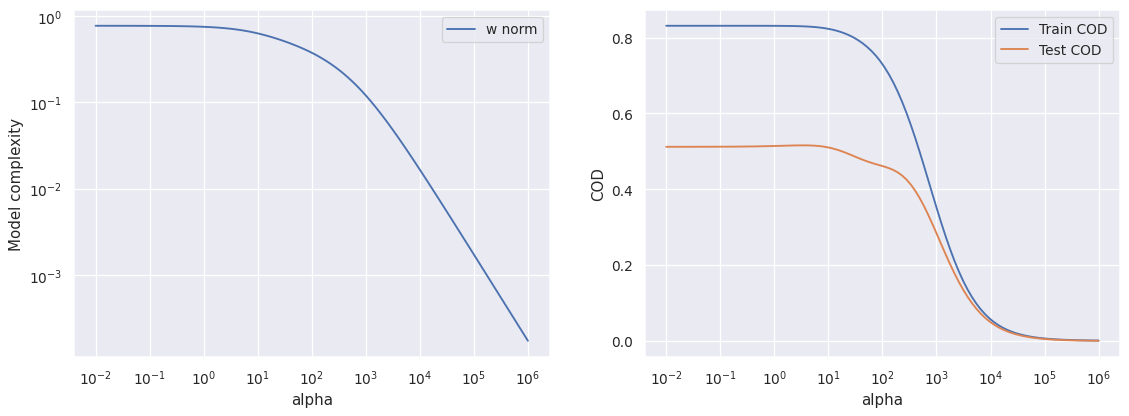

In [27]:
# Let's print model train and test metric as a function of the regularization parameter alpha (which is constraining
# model complexity, the higher the norm of w the higher model complexity)

alphas = np.logspace(-2, 6, 100)
# alphas = np.linspace(1e-2, 1e6, 100)
ridge_results = [solve_ridge_LS_problem(x_train, y_train, x_test, y_test, a) for a in alphas]

train_CODs = list(zip(*ridge_results))[0]
test_CODs = list(zip(*ridge_results))[1]
all_w_hat = list(zip(*ridge_results))[2]

fig, axes = plt.subplots(1,2, figsize=(15, 5))
axes[0].plot(alphas, list(map(np.linalg.norm, all_w_hat)), label='w norm')
axes[0].legend()
axes[0].set_xlabel('alpha')
axes[0].set_ylabel('Model complexity')

axes[1].plot(alphas, train_CODs, label='Train COD')
axes[1].plot(alphas, test_CODs, label='Test COD')
axes[1].legend()
axes[1].set_xlabel('alpha')
axes[1].set_ylabel('COD')

# If you would like to see these plots in log scale in x or y or both just uncomment the following lines
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[1].set_xscale('log')
# R² can be negative: retain a linear vertical scale.


In [28]:
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler

def CV_by_hand(num_folds,model_class,other_model_hyper_parameters,loss,hyper_param_range,x_train,y_train):
    """Return total held-out squared error / N for each alpha.

    The supplied loss must return a sum over observations (as RSS does).
    Refit scaling inside each fold to avoid validation leakage.
    """
    X,y = np.asarray(x_train),np.asarray(y_train)
    folds = list(KFold(n_splits=num_folds,shuffle=True,random_state=ID_number).split(X))
    scores = np.zeros(len(hyper_param_range))
    for i,alpha in enumerate(hyper_param_range):
        for tr,va in folds:
            params = dict(other_model_hyper_parameters)
            if model_class is linear_model.Lasso:
                params.setdefault('max_iter',50000)
                params.setdefault('tol',1e-5)
            model = make_pipeline(StandardScaler(), TransformedTargetRegressor(
                regressor=model_class(alpha=alpha,**params), transformer=StandardScaler()))
            model.fit(X[tr],y[tr])
            scores[i] += loss(y[va],X[va],model)
    return scores/len(y)

n_alphas,num_folds = 100,5
alphas = np.logspace(-3,3, n_alphas)
loss = lambda y_val,x_val,model: np.sum((y_val-model.predict(x_val))**2)
loss_ridge_kfold = CV_by_hand(num_folds,linear_model.Ridge,{},loss,alphas,x_train,y_train)
assert loss_ridge_kfold.shape == (n_alphas,)
best_index = np.argmin(loss_ridge_kfold)
ridge_alpha_opt = alphas[best_index]


In [29]:
COD_train_ridge_opt, COD_test_ridge_opt, w_hat_ridge_opt = solve_ridge_LS_problem(x_train, y_train, x_test, y_test, ridge_alpha_opt)

print(f"Best value of the regularization parameter: {ridge_alpha_opt:.4f}")
# Let's print model performance on train and test datasets (measured using COD)
print(f"Coefficient of determination on training data: {COD_train_ridge_opt:.4f}")
print(f"Coefficient of determination on test data:     {COD_test_ridge_opt:.4f}")


Best value of the regularization parameter: 61.3591
Coefficient of determination on training data: 0.7660
Coefficient of determination on test data:     0.4699


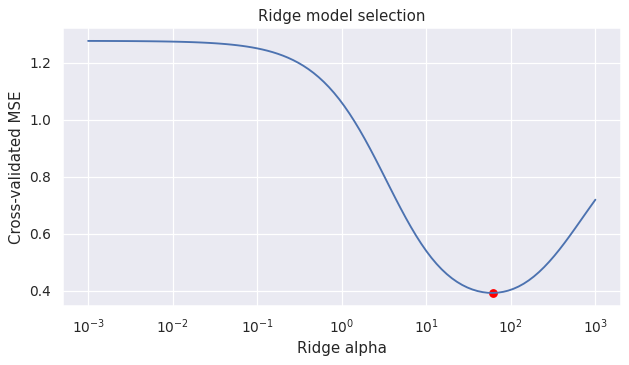

In [30]:
plt.figure(figsize=(8,4))
plt.semilogx(alphas,loss_ridge_kfold)
plt.scatter(ridge_alpha_opt,loss_ridge_kfold[best_index],color='red')
plt.xlabel('Ridge alpha'); plt.ylabel('Cross-validated MSE'); plt.title('Ridge model selection')
plt.show()


## LASSO

In the following we will apply a different regularization to our linear model: LASSO - Least Absolute Shrinkage and Selection Operator (l1 regularization)

You will code the same function as above, using functions from the Scikit-learn module, to solve the lasso LS problem for a fixed value of the regularization hyper-parameter.

After that, use the routine `lasso_path` from `sklearn.linear_regression` to compute the "lasso path" for different values of the regularization parameter $\lambda$. You should first fix a grid of possible values of lambda (the variable `lasso_lams`). For each entry of the vector `lasso_lams` you should compute the corresponding model (The $i-$th column of the vector  `lasso_coefs` should contain the coefficients of the linear model computed using `lasso_lams[i]` as regularization parameter).

Be careful that the grid should be chosen appropriately.

**Note**: the parameter $\lambda$ is called $\alpha$ in the Lasso model from sklearn.


In [31]:
def solve_lasso_LS_problem(x_train,y_train,x_test,y_test,lam):
    return model_results(linear_model.Lasso(alpha=lam,max_iter=50000,tol=1e-5),x_train,y_train,x_test,y_test)

lam = 0.1
COD_train_lasso,COD_test_lasso,w_hat_lasso = solve_lasso_LS_problem(x_train,y_train,x_test,y_test,lam)
print("Lasso training R²:",COD_train_lasso,"Test R²:",COD_test_lasso)


Lasso training R²: 0.7593362267935171 Test R²: 0.5550139906241125


In [32]:
assert w_hat_lasso.shape == (18,)


In [33]:
from sklearn.linear_model import lasso_path
num_lambdas = 100
lasso_lams = np.logspace(0,-4,num_lambdas)
# The inputs and target are centered; lasso_path does not fit an intercept.
lasso_lams,lasso_coefs,lasso_dual_gaps = lasso_path(x_train,y_train,alphas=lasso_lams,max_iter=50000,tol=1e-5)


In [34]:
assert lasso_coefs.shape == (17, num_lambdas)


Evaluate the sparsity in the estimated coefficients as a function of the regularization parameter $\lambda$: to this purpose, compute the number of non-zero entries in the estimated coefficient vector.

Text(0, 0.5, 'i-th parameter value')

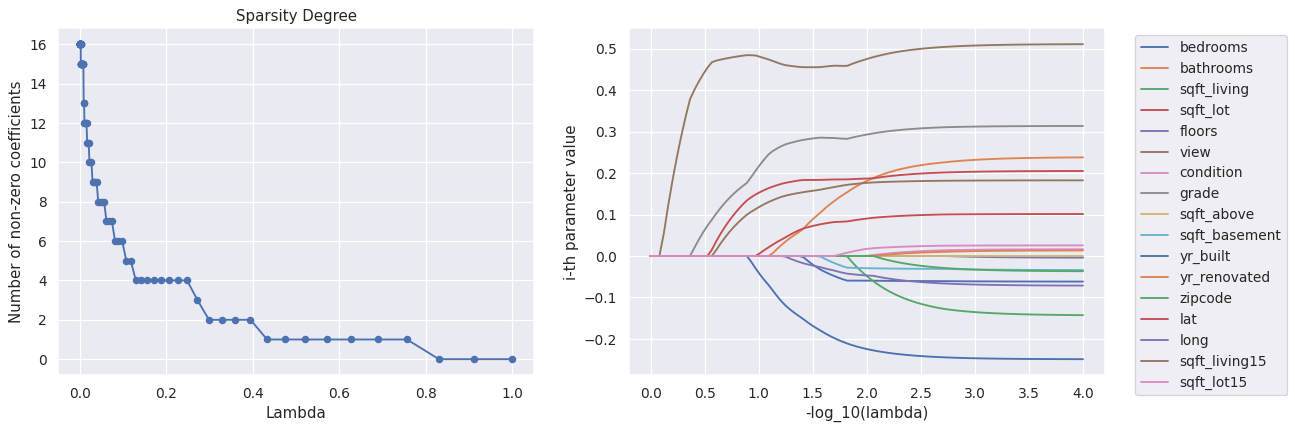

In [35]:
number_non_zero_coeffs = np.zeros(len(lasso_lams),)
# The number of non zero coeffs must be evaluated for each lambda
number_non_zero_coeffs = np.count_nonzero(np.abs(lasso_coefs)>1e-8,axis=0)

fig, axes = plt.subplots(1,2, figsize=(15, 5))
axes[0].plot(lasso_lams, number_non_zero_coeffs, marker='o', markersize=5)
axes[0].set_xlabel('Lambda')
axes[0].set_ylabel('Number of non-zero coefficients')
axes[0].set_title('Sparsity Degree')

neg_log_alphas_lasso = -np.log10(lasso_lams) # This is used only to make a nice plot (you can directly use: lasso_lams as x value)
for i, coef_l in enumerate(lasso_coefs):
    l1 = axes[1].plot(neg_log_alphas_lasso, coef_l, label=features_names[i])
axes[1].legend(bbox_to_anchor=(1.05, 1))
axes[1].set_xlabel('-log_10(lambda)')
axes[1].set_ylabel('i-th parameter value')


In [36]:
assert len(number_non_zero_coeffs) == num_lambdas


### TODO 11: explain the results in the figures above (max 5 lines)
What does each plot mean? Did you observe what you would have expected from the theory?
Type your answer in the next cell (no code needed)

The first plot counts nonzero slopes at each $\lambda$; stronger L1 regularization typically produces a sparser model, reaching all-zero slopes when the penalty is sufficiently large. The second traces each coefficient against $-\log_{10}\lambda$, so moving right weakens regularization. Exact zeros are characteristic of Lasso, unlike Ridge's continuous shrinkage. Individual coefficients can enter or leave as correlated predictors compete; strict monotonicity of every support path is not guaranteed.


In [37]:
# TODO 12
# Use Cross-Validation to find the optimal lam. You should use the CV function you implemented earlier.
# Once the omptimal lambda has been found, the following cell will automatically print its training and test error
num_folds, num_lambdas = 5, 100
lambdas = np.logspace(-4,0,num_lambdas)


model_class = linear_model.Lasso
other_model_hyper_parameters = {} # {'max_iter':10000} use this if you want to increase the number of iteration 
                                  # of the optimization not required 
loss = lambda y_val, x_val, model: np.linalg.norm(y_val - model.predict(x_val))**2

# Perform CV with your implemented function
loss_lasso_kfold = CV_by_hand(num_folds, model_class, other_model_hyper_parameters, loss, lambdas, x_train, y_train)

# Do not worry if you get the warning ("Objective did not converge"). You may try to increase the number of iterations,
# but the execution time will increase.


Best value of the regularization parameter: 0.0811
Coefficient of determination on training data: 0.7758
Coefficient of determination on test data:     0.5702
Total number of coefficients: 18
Number of non-zero coefficients: 7


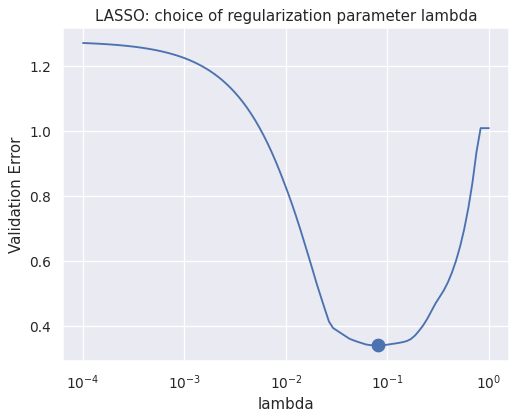

In [38]:
assert loss_lasso_kfold.shape == (num_lambdas,)

# Choose the regularization parameter that minimizes the validation loss
best_index = np.argmin(loss_lasso_kfold)
lasso_lambda_opt = lambdas[best_index]


plt.figure()
plt.plot(lambdas, loss_lasso_kfold, color='b')
plt.scatter(lasso_lambda_opt, loss_lasso_kfold[best_index], color='b', marker='o', linewidths=5)
plt.xlabel('lambda')
plt.ylabel('Validation Error')
plt.title('LASSO: choice of regularization parameter lambda')
plt.xscale('log')
plt.show()

COD_train_lasso_opt, COD_test_lasso_opt, w_hat_lasso_opt = solve_lasso_LS_problem(x_train, y_train, x_test, y_test, 
                                                                                  lasso_lambda_opt)

print(f"Best value of the regularization parameter: {lasso_lambda_opt:.4f}")
# Let's print model performance on train and test datasets (measured using COD)
print(f"Coefficient of determination on training data: {COD_train_lasso_opt:.4f}")
print(f"Coefficient of determination on test data:     {COD_test_lasso_opt:.4f}")
print("Total number of coefficients:", len(w_hat_lasso_opt))
print("Number of non-zero coefficients:", sum(w_hat_lasso_opt != 0))


In [39]:
# Let's print some performance metrics of the models we defined throughout the notebook
columns = ['COD_Train', 'COD_Test']
dict_results = {'LS_full': [COD_train_LS_full, COD_test_LS_full],
                'LS_reduced_hand': [COD_train_LS_reduced, COD_test_LS_reduced],
                'LS_reduced_BSS': [COD_train_BSS, COD_test_BSS],
                'ridge_opt': [COD_train_ridge_opt, COD_test_ridge_opt],
                'lasso_opt': [COD_train_lasso_opt, COD_test_lasso_opt] 
               }
results = pd.DataFrame.from_dict(dict_results, orient='index', columns=columns)
results['Gen_gap'] = np.abs(results['COD_Train'] - results['COD_Test'])
results


,COD_Train,COD_Test,Gen_gap
LS_full,0.831130,0.511759,0.319372
LS_reduced_hand,0.695539,0.608152,0.087387
LS_reduced_BSS,0.734955,0.487147,0.247808
ridge_opt,0.766021,0.469895,0.296125
lasso_opt,0.775817,0.570214,0.205604


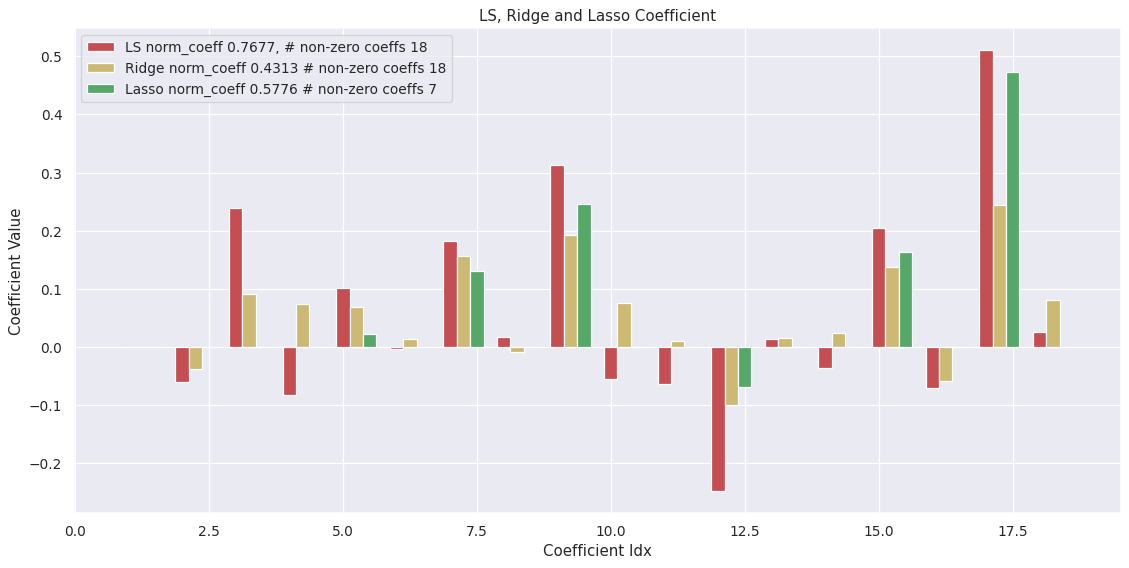

In [40]:
# Let's compare the final coefficients
ind = np.arange(1, len(w_hat_lasso_opt) + 1)  # the x locations for the groups
width = 0.25       # the width of the bars
fig, ax = plt.subplots(figsize=(15,7))
rects1 = ax.bar(ind,             w_LS_full,        width, color='r', 
                label=f'LS norm_coeff {np.linalg.norm(w_LS_full):.4}, # non-zero coeffs {sum(w_LS_full != 0)}')
rects2 = ax.bar(ind + width,     w_hat_ridge_opt , width, color='y',
               label=f'Ridge norm_coeff {np.linalg.norm(w_hat_ridge_opt):.4} # non-zero coeffs {sum(w_hat_ridge_opt != 0)}')
rects3 = ax.bar(ind + 2 * width, w_hat_lasso_opt , width, color='g',
               label=f'Lasso norm_coeff {np.linalg.norm(w_hat_lasso_opt):.4} # non-zero coeffs {sum(w_hat_lasso_opt != 0)}')
plt.xlabel('Coefficient Idx')
plt.ylabel('Coefficient Value')
plt.title('LS, Ridge and Lasso Coefficient')
plt.legend()


### TODO 13

Compare and comment the results obtained so far: did you get what you would have expected from the theory?
Type your answer in the next cell (no code needed)

With seed 42, full least squares has training/test R² of 0.8311/0.5118. The manual four-feature model gives 0.6955/0.6082, validation-selected best subset 0.7350/0.4871, CV Ridge 0.7660/0.4699, and CV Lasso 0.7758/0.5702. Thus the manual model has the best test score among these experiments, and Lasso improves on full least squares while Ridge does not on this split. The tuned penalties are Ridge alpha 61.3591 and Lasso alpha 0.08111. This is consistent with regularization's bias–variance tradeoff being an expected benefit, not a guarantee for one small sample. Ridge shrinks weights continuously; Lasso selects a sparse representation. Do not retune using this test ranking.

### How do LS, Ridge and LASSO reject redundant/useless features?
In the next TODOs we are going to create two new hand-crafted datasets: 
- first we simply replicate same features a certain number of times (so that we will have redundant features)
- second we simply replicate same features and we add some noise over them

Let's see how the models we studied so far behaves in presence of this kind of nuisances.

In [41]:
# Let's first create a function to train and print in one shot all the quantities we are interested on: Training COD,
# Test COD, model parameters.

def solve_Ls_Ridge_Lasso(x_train : np.ndarray, y_train : np.array, x_test : np.ndarray, y_test : np.array):
    # Solve Ordinary LS
    COD_train_LS_full, COD_test_LS_full, w_LS_full = solve_LS_problem(x_train, y_train, x_test, y_test)
    num_folds, n_alphas, num_lambdas = 5, 100, 100
    loss = lambda y_val, x_val, model: np.linalg.norm(y_val - model.predict(x_val))**2
    
    # Solve Ridge 
    alphas = np.logspace(-3,3, num = n_alphas)
    loss_ridge_kfold = CV_by_hand(num_folds, linear_model.Ridge, {}, loss, alphas, x_train, y_train)
    best_index_ridge = np.argmin(loss_ridge_kfold)
    ridge_alpha_opt = alphas[best_index_ridge]
    COD_train_ridge_opt, COD_test_ridge_opt, w_hat_ridge_opt = solve_ridge_LS_problem(x_train, y_train, x_test, y_test, 
                                                                                      ridge_alpha_opt)
    
    # Solve LASSO
    lambdas = np.logspace(-4,0, num = num_lambdas)
    loss_lasso_kfold = CV_by_hand(num_folds, linear_model.Lasso, {}, loss, lambdas, x_train, y_train)
    best_index = np.argmin(loss_lasso_kfold)
    lasso_lambda_opt = lambdas[best_index]
    COD_train_lasso_opt, COD_test_lasso_opt, w_hat_lasso_opt = solve_lasso_LS_problem(x_train, y_train, x_test, y_test, 
                                                                                      lasso_lambda_opt)
    
    # The following is simply a copy and paste of what we have done earlier
    columns = ['COD_Train', 'COD_Test','w_opt']
    dict_results = {
                    'LS_full': [COD_train_LS_full, COD_test_LS_full,w_LS_full],
                    'ridge_opt': [COD_train_ridge_opt, COD_test_ridge_opt,w_hat_ridge_opt],
                    'lasso_opt': [COD_train_lasso_opt, COD_test_lasso_opt,w_hat_lasso_opt]
                   }
    results = pd.DataFrame.from_dict(dict_results, orient='index', columns=columns)
    results['Gen_gap'] = np.abs(results['COD_Train'] - results['COD_Test'])

    # Let's compare the final coefficients
    ind = np.arange(1, len(w_hat_lasso_opt) + 1)  # the x locations for the groups
    width = 0.25       # the width of the bars
    fig, ax = plt.subplots(figsize=(15,7))
    rects1 = ax.bar(ind,             w_LS_full,        width, color='r', 
                    label=f'LS norm_coeff {np.linalg.norm(w_LS_full):.4}, # non-zero coeffs {sum(w_LS_full != 0)}')
    rects2 = ax.bar(ind + width,     w_hat_ridge_opt , width, color='y',
                   label=f'Ridge norm_coeff {np.linalg.norm(w_hat_ridge_opt):.4} # non-zero coeffs {sum(w_hat_ridge_opt != 0)}')
    rects3 = ax.bar(ind + 2 * width, w_hat_lasso_opt , width, color='g',
                   label=f'Lasso norm_coeff {np.linalg.norm(w_hat_lasso_opt):.4} # non-zero coeffs {sum(w_hat_lasso_opt != 0)}')
    plt.xlabel('Coefficient Idx')
    plt.ylabel('Coefficient Value')
    plt.title('LS, Ridge and Lasso Coefficient')
    plt.legend()
    
    return results, fig, ridge_alpha_opt


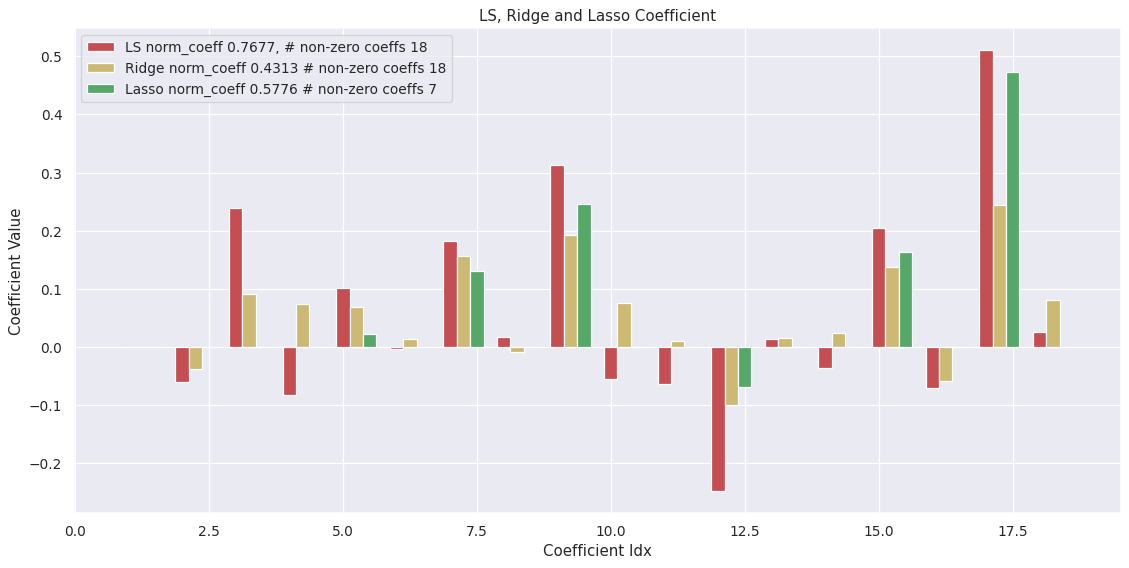

In [42]:
old_results, old_fig, _ = solve_Ls_Ridge_Lasso(x_train, y_train, x_test, y_test)


In [43]:
# We should now see the very same results we obtained earlier
old_results


,COD_Train,COD_Test,w_opt,Gen_gap
LS_full,0.831130,0.511759,"[-2.7293108039226393e-15, -0.06170248743455953...",0.319372
ridge_opt,0.766021,0.469895,"[5.615695729984652e-15, -0.03918438600592641, ...",0.296125
lasso_opt,0.775817,0.570214,"[-6.4421776760495555e-15, -0.0, 0.0, 0.0, 0.02...",0.205604


In [44]:
def replicate_a_random_feature(x_train,x_test,chosen_feature):
    return (np.column_stack((x_train,x_train[:,chosen_feature])),
            np.column_stack((x_test,x_test[:,chosen_feature])))

def add_random_feature(x_train,x_test,chosen_feature):
    # The exercise docstring and assertion specify variance 0.5 (not std 0.5).
    return (np.column_stack((x_train,x_train[:,chosen_feature]+np.random.normal(0,np.sqrt(0.5),len(x_train)))),
            np.column_stack((x_test,x_test[:,chosen_feature]+np.random.normal(0,np.sqrt(0.5),len(x_test)))))


In [45]:
replicated_x_train, replicated_x_test = replicate_a_random_feature(x_train, x_test,8)
added_x_train, added_x_test = add_random_feature(x_train, x_test,8)

assert (x_train.shape[0], x_train.shape[1] + 1) ==  replicated_x_train.shape
assert (x_test.shape[0], x_test.shape[1] + 1) ==  replicated_x_test.shape

assert (x_train.shape[0], x_train.shape[1] + 1) ==  added_x_train.shape
assert (x_test.shape[0], x_test.shape[1] + 1) ==  added_x_test.shape

assert np.isclose((added_x_train[:,-1]-x_train[:,8]).mean(), 0., atol=4e-1)
assert np.isclose((added_x_train[:,-1]-x_train[:,8]).var(), 0.5, atol=0.5)


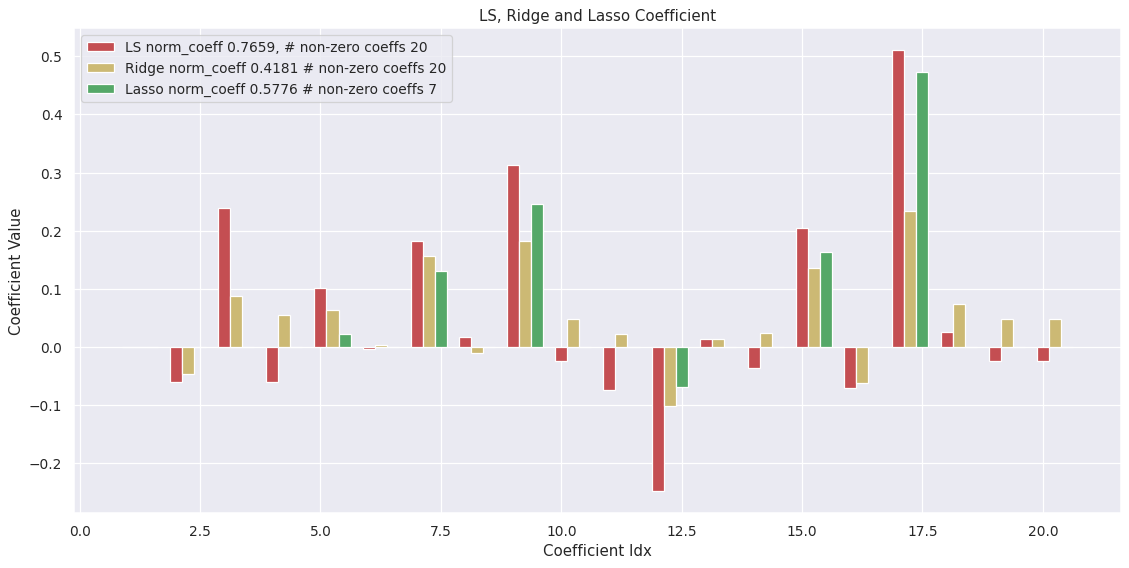

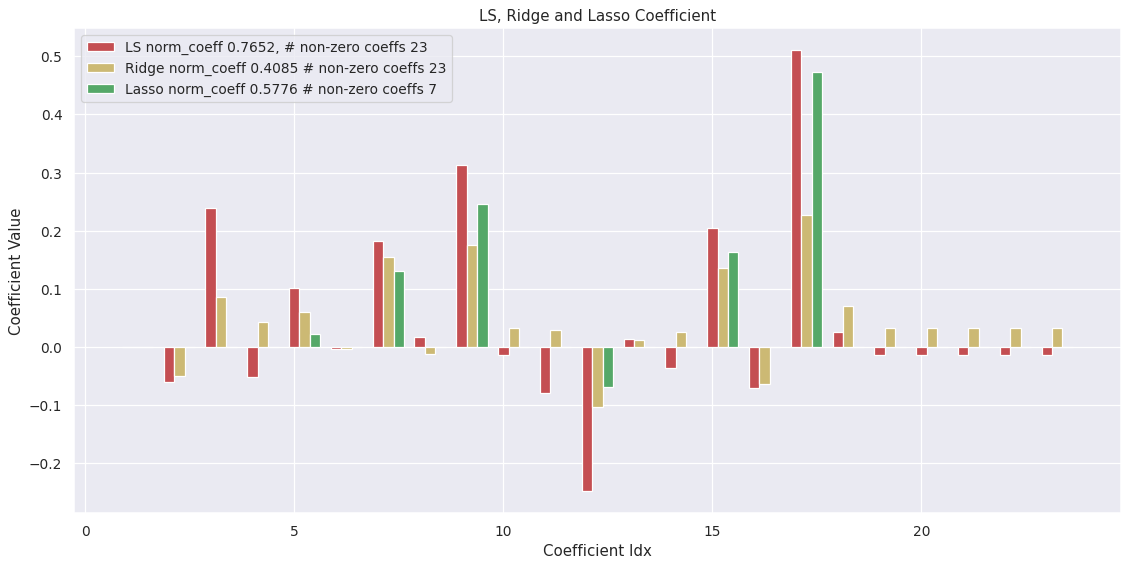

In [46]:
replicated_x_train, replicated_x_test = replicate_a_random_feature(x_train, x_test,8)
num_duplicated_features, checkpoints = 6, [2,5]
results_at_checkpoints, figs_at_checkpoints = [], []
for i in range(1, num_duplicated_features):
    if i in checkpoints:
        results, fig, _ = solve_Ls_Ridge_Lasso(replicated_x_train, y_train, replicated_x_test, y_test)
        results_at_checkpoints.append(results)
        figs_at_checkpoints.append(fig)
    replicated_x_train, replicated_x_test = replicate_a_random_feature(replicated_x_train, replicated_x_test,8) 


In [47]:
for checkpoint, results in zip(checkpoints, results_at_checkpoints):
    print(checkpoint, results)


2            COD_Train  ...   Gen_gap
LS_full     0.831130  ...  0.319372
ridge_opt   0.763543  ...  0.269135
lasso_opt   0.775817  ...  0.205604

[3 rows x 4 columns]
5            COD_Train  ...   Gen_gap
LS_full     0.831130  ...  0.319372
ridge_opt   0.761443  ...  0.253196
lasso_opt   0.775817  ...  0.205604

[3 rows x 4 columns]


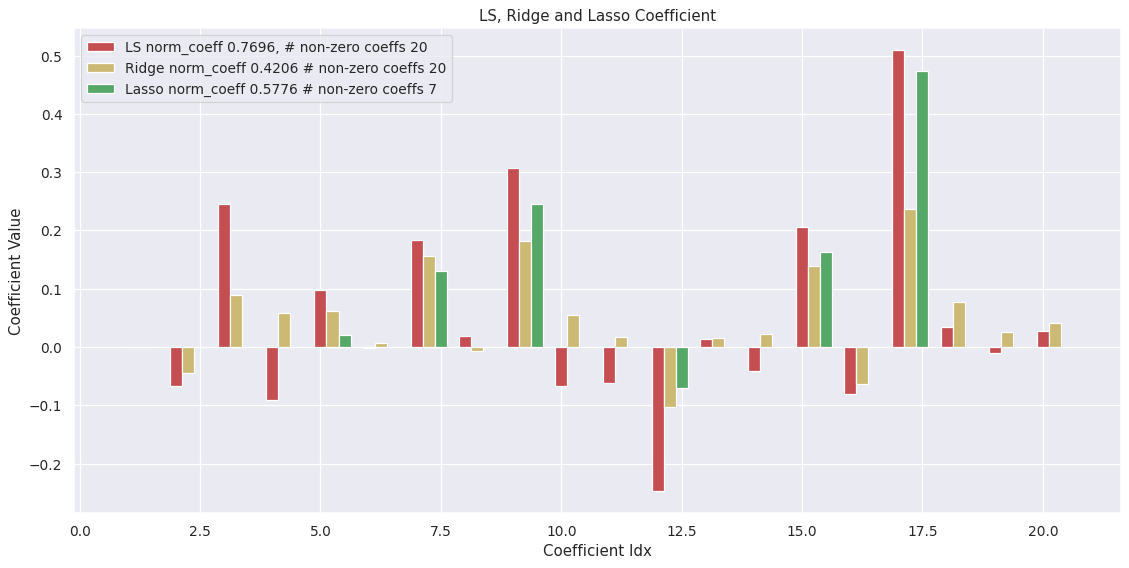

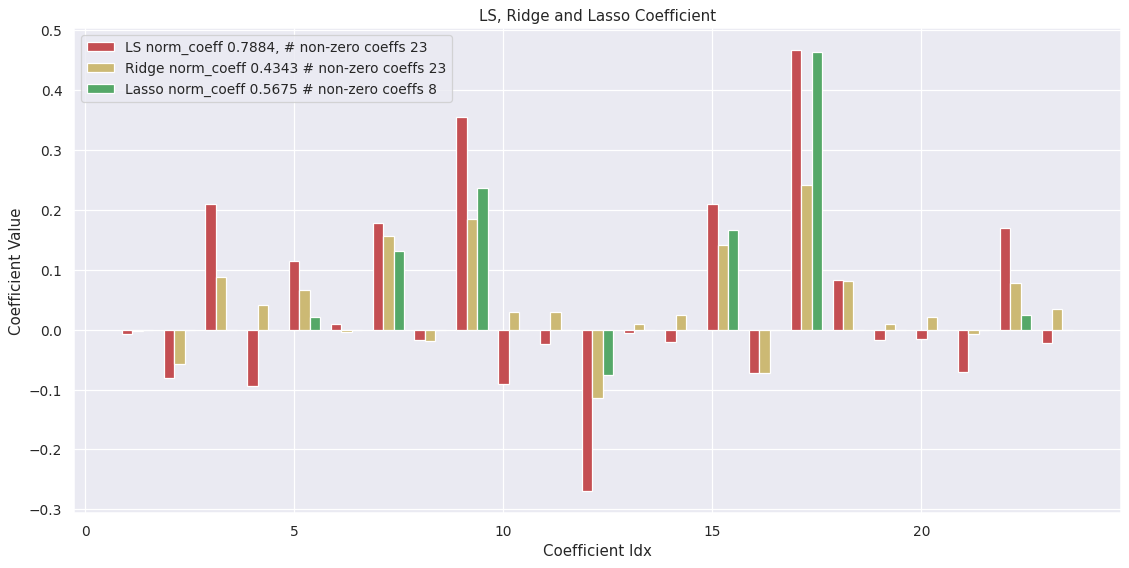

In [48]:
added_x_train, added_x_test = add_random_feature(x_train, x_test,8)
num_added_features, checkpoints = 6, [2,5]
added_results_at_checkpoints, added_figs_at_checkpoints = [], []
for i in range(1, num_added_features):
    if i in checkpoints:
        results, fig, bbb = solve_Ls_Ridge_Lasso(added_x_train, y_train, added_x_test, y_test)
        added_results_at_checkpoints.append(results)
        added_figs_at_checkpoints.append(fig)
    added_x_train, added_x_test = add_random_feature(added_x_train, added_x_test,8)  


In [49]:
for checkpoint, results in zip(checkpoints, added_results_at_checkpoints):
    print(checkpoint, results)


2            COD_Train  ...   Gen_gap
LS_full     0.831495  ...  0.327979
ridge_opt   0.763688  ...  0.277336
lasso_opt   0.775817  ...  0.205604

[3 rows x 4 columns]
5            COD_Train  ...   Gen_gap
LS_full     0.846485  ...  0.491653
ridge_opt   0.779835  ...  0.303735
lasso_opt   0.778821  ...  0.202829

[3 rows x 4 columns]


### TODO 15 

Comment in the next cell the results obtained using LS, Ridge and LASSO after we added redundant/useless features.

Exact duplicated columns do not enlarge the prediction space, but make ordinary least-squares coefficients nonunique; the minimum-norm solution divides their combined effect among identical columns. Ridge has a unique solution for positive penalty and distributes weight across duplicates. Duplicating a predictor also reduces the effective Ridge penalty on its total contribution, so even predictions can change. Lasso can concentrate the contribution on one copy, with nonunique allocations among identical predictors. Noisy copies can inflate variance and invite overfitting; regularization can help, but their coefficients and the test ranking depend on the sample. Compare the checkpoint tables rather than assuming every additional feature must worsen test error.


In this run, exact duplicates leave full least-squares training R² at 0.8311 and test R² at approximately 0.5118, while redistributing coefficients. With five added noisy copies, full least squares rises to approximately 0.8465 training R² but falls to 0.3548 test R²; this is a clear overfitting pattern. Ridge's corresponding test R² is approximately 0.4761, and Lasso's is 0.5760. The regularized models are more resistant to this particular nuisance-feature experiment, without implying universal superiority.